# Mini-Project — Data Analysis for Marketing Strategy

**Dataset:** US Superstore Dataset (reused from Day 4's discount analysis) 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('superstore_dataset.csv', encoding='latin1')

print("Shape:", df.shape)
print("Duplicates:", df.duplicated().sum())
print("Missing values:\n", df.isnull().sum().sum())

df['Order Date'] = pd.to_datetime(df['Order Date'])
df.head()

Shape: (9994, 21)
Duplicates: 0
Missing values:
 0


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Q1: Which states have the most sales?

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64


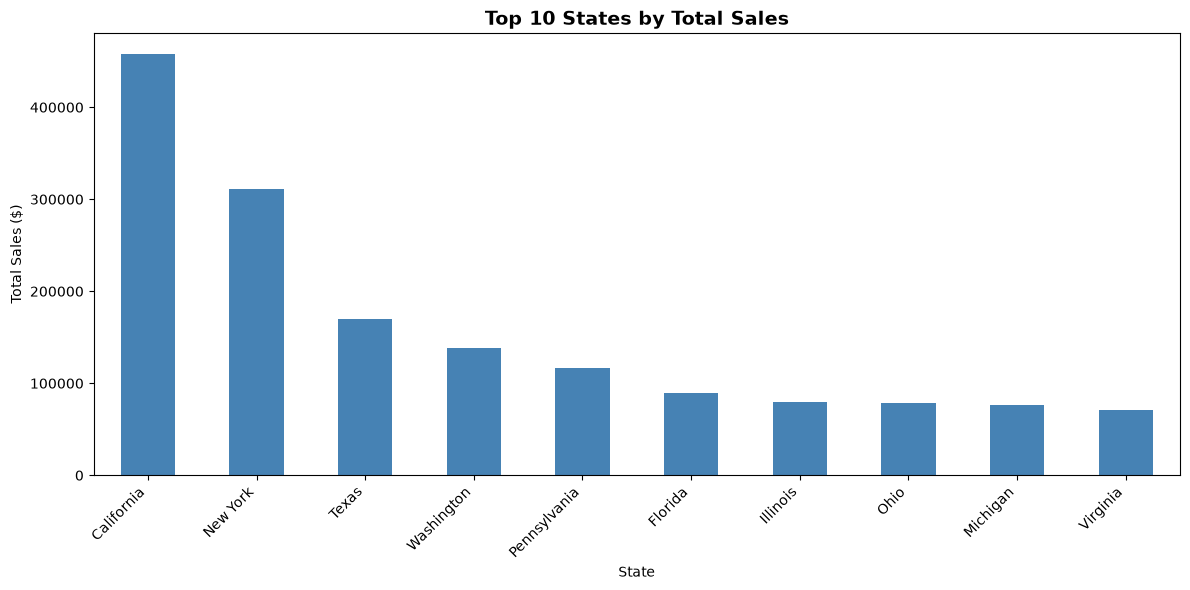

In [2]:
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)
print(state_sales.head(10))

plt.figure(figsize=(12, 6))
state_sales.head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 States by Total Sales', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

California leads by a wide margin (~$460K), followed by New York (~$310K). The remaining top 10 states cluster much lower, showing sales are heavily concentrated in just these two states.

## Q2: New York vs. California — Sales and Profit

                  Sales      Profit
State                              
California  457687.6315  76381.3871
New York    310876.2710  74038.5486


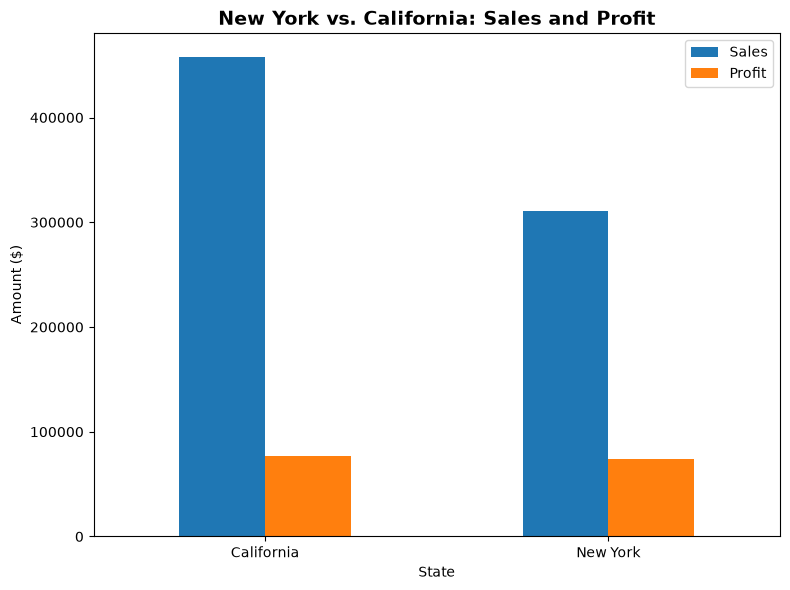

In [3]:
ny_ca = df[df['State'].isin(['New York', 'California'])].groupby('State')[['Sales', 'Profit']].sum()
print(ny_ca)

ny_ca.plot(kind='bar', figsize=(8, 6))
plt.title('New York vs. California: Sales and Profit', fontsize=14, fontweight='bold')
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

California outsells New York by a wide margin ($457K vs $310K, ~48% more), but their profits are nearly identical (~$77K vs ~$74K). This means New York converts sales into profit far more efficiently than California — California needs significantly more revenue to generate a comparable profit, suggesting California may have higher discounting, costs, or less profitable product mix.

## Q3: Who is an outstanding customer in New York?

In [4]:
ny_customers = df[df['State'] == 'New York'].groupby('Customer Name')[['Sales', 'Profit']].sum().sort_values('Profit', ascending=False)
print(ny_customers.head(10))

                      Sales     Profit
Customer Name                         
Tom Ashbrook      13723.498  4599.2073
Keith Dawkins      5854.194  2510.8903
Karen Daniels      6241.282  2283.0463
Nathan Mautz       4821.292  2247.1904
Tom Boeckenhauer   6999.960  2239.9872
Steven Roelle      3904.680  1863.9614
Pete Kriz          4816.690  1695.3209
Darrin Martin      4283.792  1599.6806
Todd Sumrall       6492.314  1574.9714
Seth Vernon        7359.918  1571.7964


**Tom Ashbrook** is the standout customer in New York — $13,723 in sales and $4,599 in profit, more than double the second-highest customer (Keith Dawkins at $2,511 profit). This customer alone accounts for a disproportionate share of New York's profitability and would be a strong candidate for a dedicated retention/loyalty strategy.

## Q4: Are there differences among states in profitability?

5 least profitable states:
 State
Texas            -25729.3563
Ohio             -16971.3766
Pennsylvania     -15559.9603
Illinois         -12607.8870
North Carolina    -7490.9122
Name: Profit, dtype: float64

5 most profitable states:
 State
Virginia      18597.9504
Michigan      24463.1876
Washington    33402.6517
New York      74038.5486
California    76381.3871
Name: Profit, dtype: float64


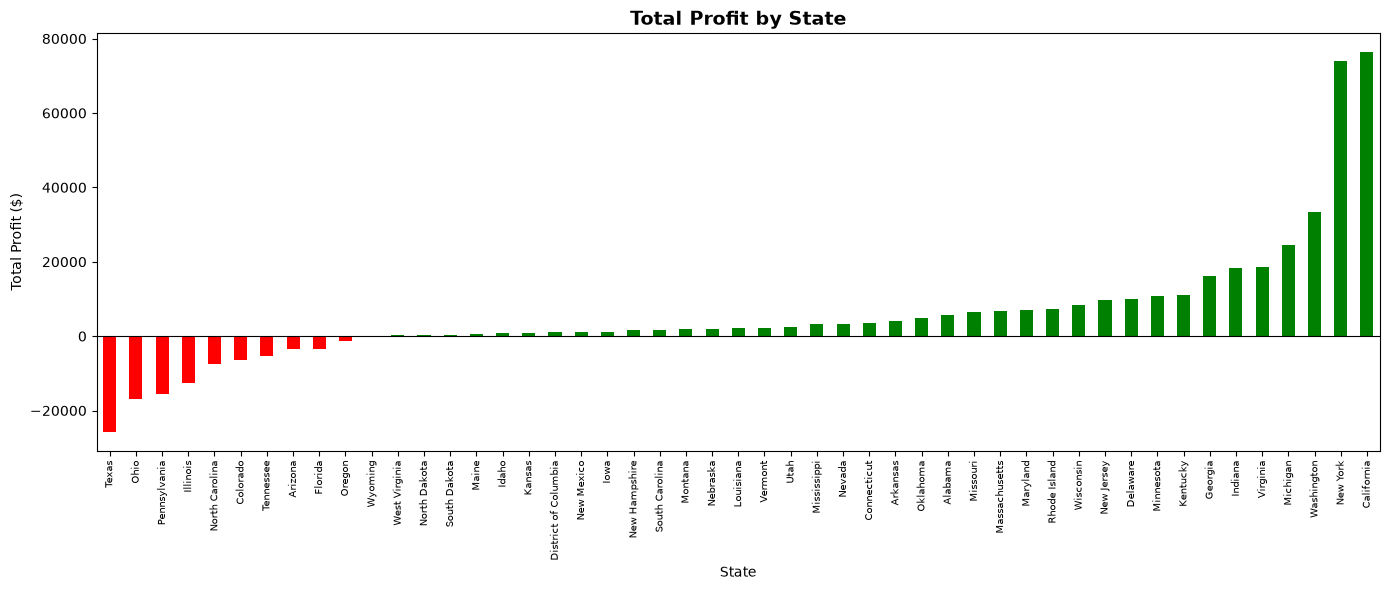

In [5]:
state_profit = df.groupby('State')['Profit'].sum().sort_values()
print("5 least profitable states:\n", state_profit.head())
print("\n5 most profitable states:\n", state_profit.tail())

plt.figure(figsize=(14, 6))
colors = ['red' if x < 0 else 'green' for x in state_profit]
state_profit.plot(kind='bar', color=colors)
plt.title('Total Profit by State', fontsize=14, fontweight='bold')
plt.ylabel('Total Profit ($)')
plt.xticks(rotation=90, fontsize=7)
plt.axhline(y=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

Profitability varies dramatically by state — 8 states (led by Texas at -$25K, then Ohio, Pennsylvania, Illinois) are net **unprofitable** overall, despite generating real sales. California and New York are both top sellers and top profit generators, but many other high-sales states (like Texas, ranked #3 in sales from Q1) actually lose money — high sales volume does not guarantee profitability, and Texas in particular is a significant loss-maker worth investigating.

## Q5: Does the Pareto Principle apply to customers and profit?

In [6]:
customer_profit = df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False)
total_profit = customer_profit.sum()
num_customers = len(customer_profit)
top_20_pct_count = int(num_customers * 0.2)

top_20_pct_profit = customer_profit.head(top_20_pct_count).sum()
top_20_pct_share = (top_20_pct_profit / total_profit) * 100

print(f"Total customers: {num_customers}")
print(f"Top 20% count: {top_20_pct_count}")
print(f"Top 20% of customers contribute: {top_20_pct_share:.1f}% of total profit")

Total customers: 793
Top 20% count: 158
Top 20% of customers contribute: 81.4% of total profit


The Pareto Principle holds strongly here: the top 20% of customers (158 out of 793) generate **81.4%** of total profit — remarkably close to the textbook 80/20 split. This confirms that profit is heavily concentrated in a relatively small group of high-value customers, reinforcing the recommendation to prioritize retention and relationship-building with this top segment.

## Q6: Top 20 Cities by Sales and Profit

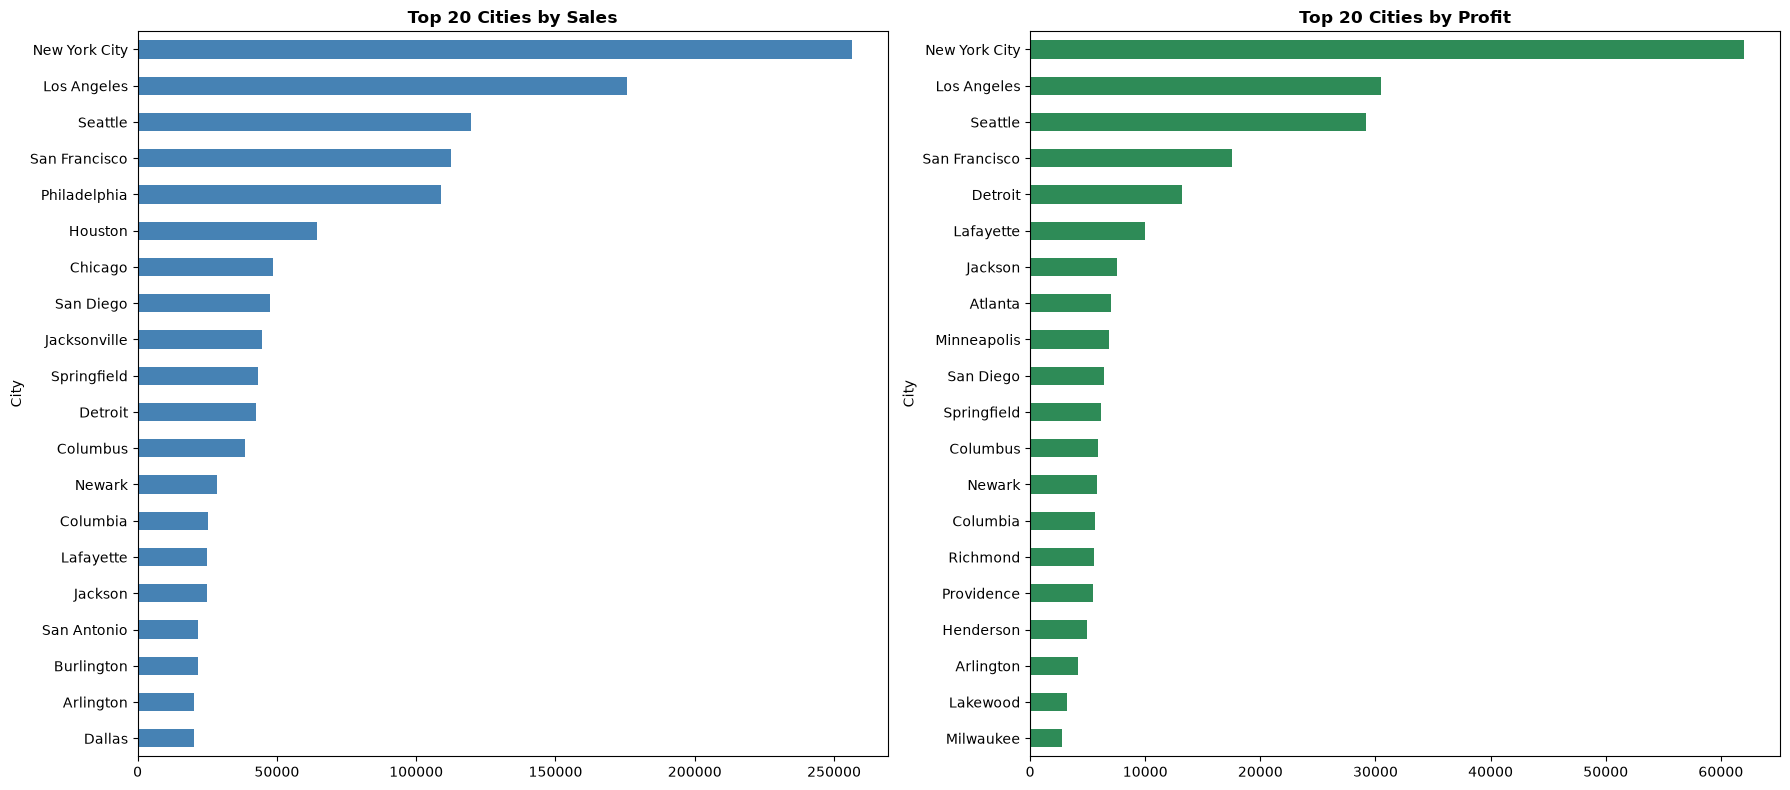

Cities in BOTH top 20 lists: 13
['Arlington', 'Columbia', 'Columbus', 'Detroit', 'Jackson', 'Lafayette', 'Los Angeles', 'New York City', 'Newark', 'San Diego', 'San Francisco', 'Seattle', 'Springfield']


In [7]:
city_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(20)
city_profit = df.groupby('City')['Profit'].sum().sort_values(ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
city_sales.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 Cities by Sales', fontweight='bold')
axes[0].invert_yaxis()

city_profit.plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Top 20 Cities by Profit', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

overlap = set(city_sales.index) & set(city_profit.index)
print(f"Cities in BOTH top 20 lists: {len(overlap)}")
print(sorted(overlap))

Only 13 of the 20 top-selling cities also rank in the top 20 by profit — meaning 7 high-sales cities significantly underperform on profitability. Dallas notably drops out of the profit ranking entirely, consistent with Texas being the state with the largest overall losses (-$25K, from Q4). This reinforces that high sales volume in Texas cities is not converting into profit, likely due to excessive discounting or unfavorable product mix — an area worth investigating before further marketing investment there.

## Q7: Top 20 Customers by Sales

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Todd Sumrall          11891.751
Greg Tran             11820.120
Becky Martin          11789.630
Seth Vernon           11470.950
Caroline Jumper       11164.974
Clay Ludtke           10880.546
Maria Etezadi         10663.728
Karen Ferguson        10604.266
Bill Shonely          10501.653
Edward Hooks          10310.880
Name: Sales, dtype: float64


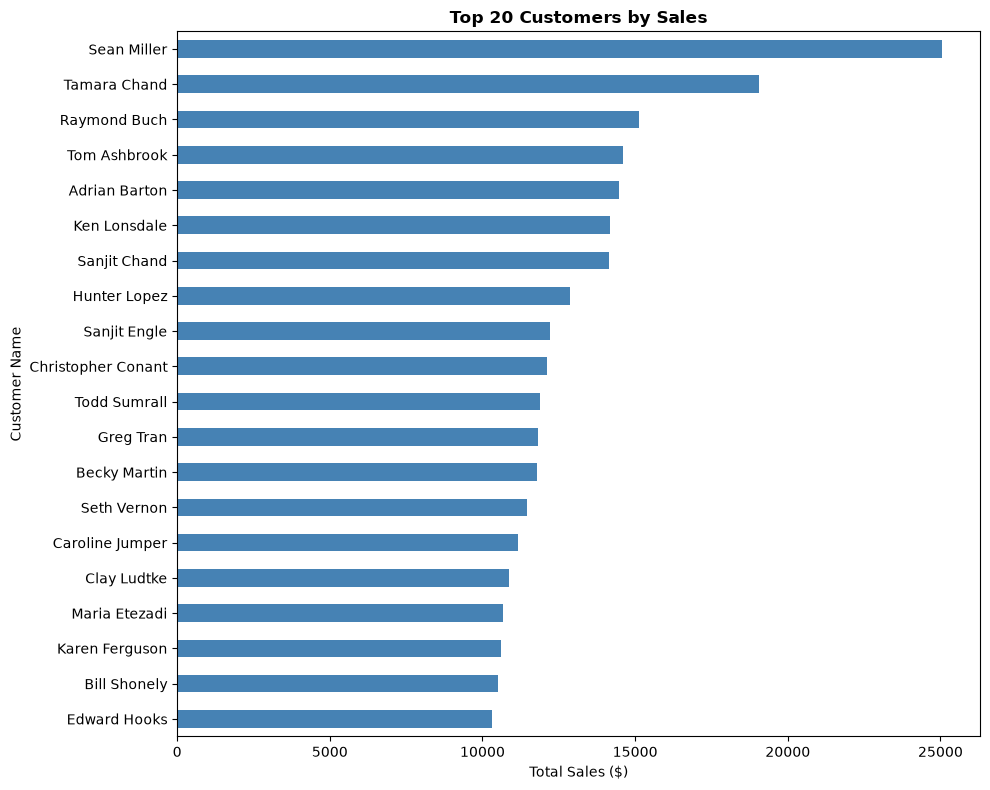

In [8]:
top_customers_sales = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(20)
print(top_customers_sales)

plt.figure(figsize=(10, 8))
top_customers_sales.plot(kind='barh', color='steelblue')
plt.title('Top 20 Customers by Sales', fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Sean Miller is the top customer nationally by sales ($25,096), ahead of Tamara Chand ($19,052). Tom Ashbrook (New York's standout customer from Q3) ranks #4 nationally ($14,595), confirming his importance isn't just a New York-specific finding — he's genuinely a top-tier customer overall.

## Q8: Cumulative Sales Curve — Does Pareto Apply to Sales Too?

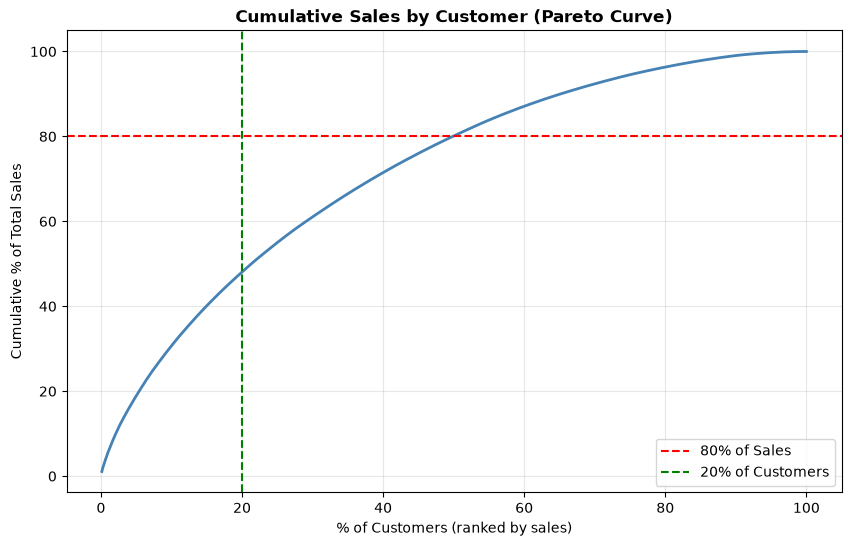

Top 20% of customers generate: 48.1% of total sales


In [9]:
customer_sales_sorted = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False)
cumulative_pct = (customer_sales_sorted.cumsum() / customer_sales_sorted.sum()) * 100
customer_pct = np.arange(1, len(customer_sales_sorted) + 1) / len(customer_sales_sorted) * 100

plt.figure(figsize=(10, 6))
plt.plot(customer_pct, cumulative_pct.values, color='steelblue', linewidth=2)
plt.axhline(y=80, color='red', linestyle='--', label='80% of Sales')
plt.axvline(x=20, color='green', linestyle='--', label='20% of Customers')
plt.title('Cumulative Sales by Customer (Pareto Curve)', fontweight='bold')
plt.xlabel('% of Customers (ranked by sales)')
plt.ylabel('Cumulative % of Total Sales')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

top_20_sales_share = cumulative_pct.iloc[int(len(cumulative_pct) * 0.2)]
print(f"Top 20% of customers generate: {top_20_sales_share:.1f}% of total sales")

Unlike profit, sales do NOT follow the Pareto principle here. The top 20% of customers account for only ~48% of total sales — it takes roughly the top 50% of customers to reach 80% of sales. This is a meaningful contrast with Q5: profit is sharply concentrated among a small group of top customers, but sales are spread much more evenly across the customer base. This means "biggest spenders" and "most profitable customers" are largely different groups — a marketing strategy that chases sales volume risks investing in customers who don't actually drive profitability.

## Q9: Final Recommendations — Marketing Strategy Priorities

**States to prioritize:**
- **California and New York** — the two clear leaders in both sales AND profit. New York is notably more capital-efficient (higher profit relative to sales), making it an attractive target for continued/expanded investment.
- **Avoid over-investing in Texas** — despite ranking #3 in sales, it's the single worst-performing state for profit (-$25K). Marketing spend here should be paused or redirected until the underlying profitability issue (likely excessive discounting) is diagnosed and fixed.

**Cities to prioritize:**
- Focus on the 13 cities that rank in the top 20 for *both* sales and profit (e.g. Los Angeles, New York City, San Francisco, San Diego, Seattle) — these are proven, reliably profitable markets.
- Investigate high-sales-but-low-profit cities like Dallas before allocating further marketing budget there.

**Customer strategy:**
- Prioritize retention for the top 20% of customers by profit — they generate 81.4% of total profit (Pareto confirmed). Standout individuals like Tom Ashbrook and Sean Miller warrant dedicated account management.
- Do not equate "top spenders" with "most valuable customers" — Q8 showed these are largely different groups, since sales don't follow the same concentrated pattern as profit.

**Overall takeaway:** marketing strategy should be guided by *profitability*, not sales volume alone. Several high-sales states, cities, and customer segments are not proportionally profitable, and resources are better spent protecting and growing the smaller group of customers and regions that are already reliably profitable.